In [1]:
from pathlib import Path
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score

import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

## Part I. Data Acquisition
Download and extract the UCI HAR dataset for the autoencoder workflow.

In [2]:
base_dir = Path("data/UCI_HAR_Dataset")
base_dir.mkdir(parents=True, exist_ok=True)

url = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
zip_path = base_dir / "UCI_HAR.zip"
extract_dir = base_dir

target_file = extract_dir / "UCI HAR Dataset" / "train" / "X_train.txt"

if not target_file.exists():
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

## Part II. Data Loading and Preprocessing
Load train/test files, clean feature names, build `df`, and standardize features for model training.

In [3]:
candidate_dirs = [
    Path("data/UCI_HAR_Dataset/UCI HAR Dataset"),
    Path("UCI_HAR_Dataset/UCI HAR Dataset"),
    Path("UCI HAR Dataset"),
]

har_dir = next((p for p in candidate_dirs if (p / "features.txt").exists()), None)
if har_dir is None:
    raise FileNotFoundError(
        "Could not find 'UCI HAR Dataset'. Run download cell first or check dataset path."
    )

features = pd.read_csv(
    har_dir / "features.txt",
    sep=r"\s+",
    header=None,
    names=["feature_idx", "feature_name"]
)
activity_labels = pd.read_csv(
    har_dir / "activity_labels.txt",
    sep=r"\s+",
    header=None,
    names=["activity_id", "activity"]
)

clean_feature_names = (
    features["feature_name"]
    .str.replace(r"[^0-9a-zA-Z]+", "_", regex=True)
    .str.strip("_")
    .str.lower()
)

name_counts = {}
unique_feature_names = []
for name in clean_feature_names:
    count = name_counts.get(name, 0)
    unique_name = name if count == 0 else f"{name}_{count}"
    unique_feature_names.append(unique_name)
    name_counts[name] = count + 1

X_train = pd.read_csv(har_dir / "train" / "X_train.txt", sep=r"\s+", header=None)
y_train = pd.read_csv(har_dir / "train" / "y_train.txt", sep=r"\s+", header=None, names=["activity_id"])
subject_train = pd.read_csv(har_dir / "train" / "subject_train.txt", sep=r"\s+", header=None, names=["subject"])

X_test = pd.read_csv(har_dir / "test" / "X_test.txt", sep=r"\s+", header=None)
y_test = pd.read_csv(har_dir / "test" / "y_test.txt", sep=r"\s+", header=None, names=["activity_id"])
subject_test = pd.read_csv(har_dir / "test" / "subject_test.txt", sep=r"\s+", header=None, names=["subject"])

X_train.columns = unique_feature_names
X_test.columns = unique_feature_names

train_df = pd.concat([subject_train, y_train, X_train], axis=1)
test_df = pd.concat([subject_test, y_test, X_test], axis=1)
df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

a_map = dict(zip(activity_labels["activity_id"], activity_labels["activity"]))
df["activity"] = df["activity_id"].map(a_map)

print(df.columns.tolist())

df.head()

['subject', 'activity_id', 'tbodyacc_mean_x', 'tbodyacc_mean_y', 'tbodyacc_mean_z', 'tbodyacc_std_x', 'tbodyacc_std_y', 'tbodyacc_std_z', 'tbodyacc_mad_x', 'tbodyacc_mad_y', 'tbodyacc_mad_z', 'tbodyacc_max_x', 'tbodyacc_max_y', 'tbodyacc_max_z', 'tbodyacc_min_x', 'tbodyacc_min_y', 'tbodyacc_min_z', 'tbodyacc_sma', 'tbodyacc_energy_x', 'tbodyacc_energy_y', 'tbodyacc_energy_z', 'tbodyacc_iqr_x', 'tbodyacc_iqr_y', 'tbodyacc_iqr_z', 'tbodyacc_entropy_x', 'tbodyacc_entropy_y', 'tbodyacc_entropy_z', 'tbodyacc_arcoeff_x_1', 'tbodyacc_arcoeff_x_2', 'tbodyacc_arcoeff_x_3', 'tbodyacc_arcoeff_x_4', 'tbodyacc_arcoeff_y_1', 'tbodyacc_arcoeff_y_2', 'tbodyacc_arcoeff_y_3', 'tbodyacc_arcoeff_y_4', 'tbodyacc_arcoeff_z_1', 'tbodyacc_arcoeff_z_2', 'tbodyacc_arcoeff_z_3', 'tbodyacc_arcoeff_z_4', 'tbodyacc_correlation_x_y', 'tbodyacc_correlation_x_z', 'tbodyacc_correlation_y_z', 'tgravityacc_mean_x', 'tgravityacc_mean_y', 'tgravityacc_mean_z', 'tgravityacc_std_x', 'tgravityacc_std_y', 'tgravityacc_std_z', 

,subject,activity_id,tbodyacc_mean_x,tbodyacc_mean_y,tbodyacc_mean_z,tbodyacc_std_x,tbodyacc_std_y,tbodyacc_std_z,tbodyacc_mad_x,tbodyacc_mad_y,...,fbodybodygyrojerkmag_skewness,fbodybodygyrojerkmag_kurtosis,angle_tbodyaccmean_gravity,angle_tbodyaccjerkmean_gravitymean,angle_tbodygyromean_gravitymean,angle_tbodygyrojerkmean_gravitymean,angle_x_gravitymean,angle_y_gravitymean,angle_z_gravitymean,activity
0,1,5,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,STANDING
1,1,5,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,STANDING
2,1,5,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,STANDING
3,1,5,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,STANDING
4,1,5,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,STANDING


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_flat = y_train["activity_id"].values
y_test_flat = y_test["activity_id"].values

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"Feature range after scaling: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=unique_feature_names)
X_train_scaled_df.head()

X_train_scaled shape: (7352, 561)
X_test_scaled shape: (2947, 561)
Feature range after scaling: [-24.07, 34.19]


,tbodyacc_mean_x,tbodyacc_mean_y,tbodyacc_mean_z,tbodyacc_std_x,tbodyacc_std_y,tbodyacc_std_z,tbodyacc_mad_x,tbodyacc_mad_y,tbodyacc_mad_z,tbodyacc_max_x,...,fbodybodygyrojerkmag_meanfreq,fbodybodygyrojerkmag_skewness,fbodybodygyrojerkmag_kurtosis,angle_tbodyaccmean_gravity,angle_tbodyaccjerkmean_gravitymean,angle_tbodygyromean_gravitymean,angle_tbodygyrojerkmean_gravitymean,angle_x_gravitymean,angle_y_gravitymean,angle_z_gravitymean
0,0.200642,-0.063683,-0.419628,-0.868814,-0.939441,-0.737529,-0.859817,-0.939019,-0.766437,-0.856036,...,-0.795359,0.025960,-0.276399,-0.360603,0.062940,-0.778427,-0.026080,-0.687219,0.407946,-0.007568
1,0.055948,0.031486,-0.253908,-0.875426,-0.923902,-0.849304,-0.868531,-0.921998,-0.848928,-0.871359,...,0.130614,-0.897357,-0.767990,0.133011,-0.021461,-1.218805,1.484470,-0.694138,0.409117,0.007875
2,0.073515,-0.043416,-0.076295,-0.869039,-0.907760,-0.893785,-0.863137,-0.898854,-0.896701,-0.863323,...,1.152336,-0.260878,-0.438316,-0.377840,0.391976,0.151207,1.704201,-0.702239,0.410288,0.026502
3,0.066696,-0.208422,-0.249712,-0.870626,-0.940022,-0.921805,-0.864503,-0.938124,-0.925279,-0.863323,...,1.112769,0.591045,0.463155,-0.135025,-0.033637,1.037851,-1.003019,-0.701684,0.414650,0.031714
4,0.030469,0.027587,-0.109848,-0.875188,-0.934878,-0.921343,-0.867384,-0.931789,-0.928028,-0.870260,...,-0.149577,-0.138515,-0.240313,0.340406,0.268486,1.125918,-1.276282,-0.700152,0.425463,0.045225


## Part III. Autoencoder Design and Training
Define encoder/decoder architecture, compile the model, configure early stopping, and train the autoencoder.

In [5]:
input_dim = 561
latent_dim = 2

encoder_input = Input(shape=(input_dim,))
x = Dense(280, activation='relu')(encoder_input)
x = Dense(140, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(16, activation='relu')(x)
latent = Dense(latent_dim, activation='linear', name='latent')(x)

encoder = Model(encoder_input, latent, name='encoder')
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 561)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 280)            │       157,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 140)            │        39,340 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         9,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,798 (807.80 KB)

 Trainable params: 206,798 (807.80 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
decoder_input = Input(shape=(latent_dim,))
x = Dense(16, activation='relu')(decoder_input)
x = Dense(64, activation='relu')(x)
x = Dense(140, activation='relu')(x)
x = Dense(280, activation='relu')(x)
decoder_output = Dense(input_dim, activation='linear')(x)

decoder = Model(decoder_input, decoder_output, name='decoder')
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 140)            │         9,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 280)            │        39,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 561)            │       157,641 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 207,357 (809.99 KB)

 Trainable params: 207,357 (809.99 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
autoencoder_input = Input(shape=(input_dim,))
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)

autoencoder = Model(autoencoder_input, decoded, name='autoencoder')
autoencoder.compile(optimizer='adam', loss='mse', metrics=['mae'])
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 561)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 2)              │       206,798 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 561)            │       207,357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 414,155 (1.58 MB)

 Trainable params: 414,155 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

In [9]:
history_ae = autoencoder.fit(
    X_train_scaled,
    X_train_scaled,
    epochs=100,
    batch_size=128,
    validation_data=(X_test_scaled, X_test_scaled),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.7325 - mae: 0.6320 - val_loss: 0.4208 - val_mae: 0.4039
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4500 - mae: 0.4054 - val_loss: 0.3889 - val_mae: 0.3796
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4083 - mae: 0.3773 - val_loss: 0.3768 - val_mae: 0.3705
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3855 - mae: 0.3680 - val_loss: 0.3683 - val_mae: 0.3668
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3818 - mae: 0.3640 - val_loss: 0.3611 - val_mae: 0.3604
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3669 - mae: 0.3564 - val_loss: 0.3483 - val_mae: 0.3474
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3544 - mae: 0.3404 - val_loss: 0.3426 - val_mae: 0.3409
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.3439 - mae: 0.3360 - val_loss: 0.3424 - val_mae: 0.3412
Epoch 9/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss

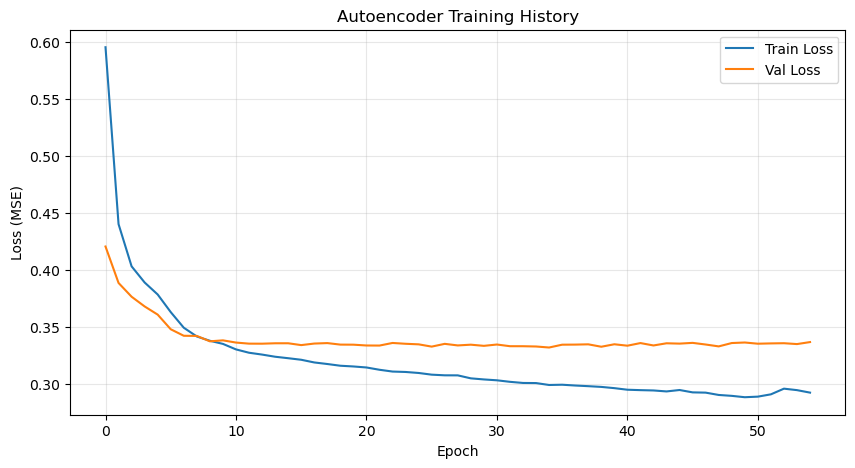

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(history_ae.history['loss'], label='Train Loss')
plt.plot(history_ae.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Autoencoder Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Part IV. Latent Space Analysis and SVM Evaluation
Visualize latent embeddings and evaluate classification performance versus the original feature space.

230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


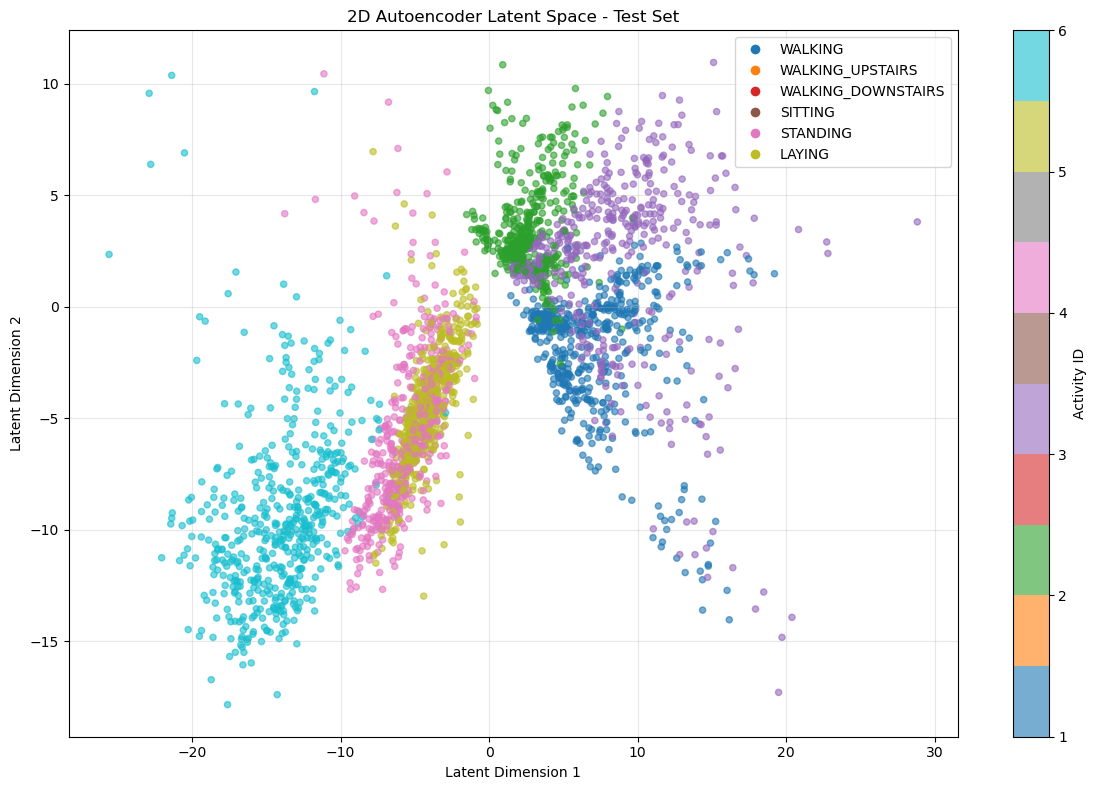

In [11]:
X_train_latent = encoder.predict(X_train_scaled)
X_test_latent = encoder.predict(X_test_scaled)

y_train_labels = y_train["activity_id"].map(a_map).values
y_test_labels = y_test["activity_id"].map(a_map).values

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_test_latent[:, 0], X_test_latent[:, 1],
                     c=y_test_flat, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Activity ID')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('2D Autoencoder Latent Space - Test Set')
plt.grid(True, alpha=0.3)

activities = activity_labels["activity"].values
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=plt.cm.tab10(i/6), markersize=8, label=activities[i])
           for i in range(6)]
plt.legend(handles=handles, loc='best')
plt.tight_layout()
plt.show()

SVM Accuracy on 2D AE Latent Features: 0.7815

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.76      0.96      0.84       496
  WALKING_UPSTAIRS       0.84      0.84      0.84       471
WALKING_DOWNSTAIRS       0.84      0.58      0.68       420
           SITTING       0.76      0.36      0.49       491
          STANDING       0.62      0.94      0.75       532
            LAYING       0.99      0.95      0.97       537

          accuracy                           0.78      2947
         macro avg       0.80      0.77      0.76      2947
      weighted avg       0.80      0.78      0.77      2947



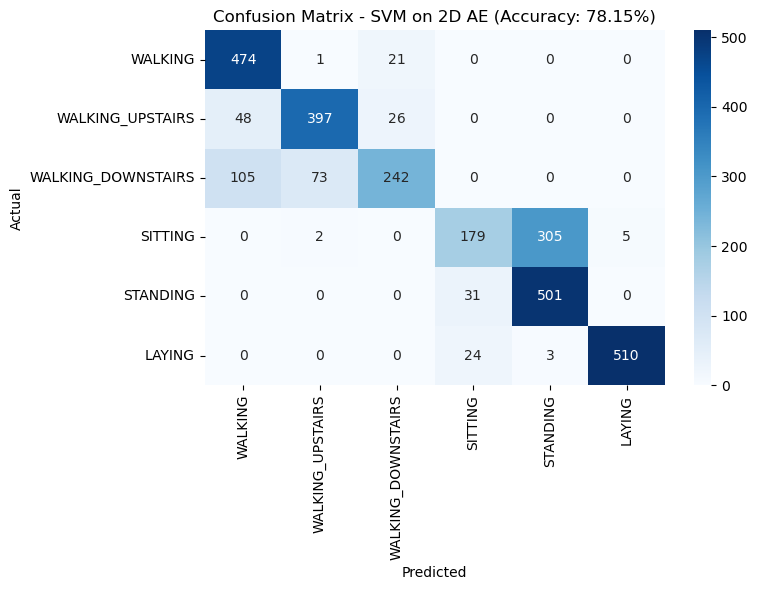

In [12]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

svm_ae = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_ae.fit(X_train_latent, y_train_flat)

y_pred_svm_ae = svm_ae.predict(X_test_latent)
acc_svm_ae = accuracy_score(y_test_flat, y_pred_svm_ae)

print(f"SVM Accuracy on 2D AE Latent Features: {acc_svm_ae:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_flat, y_pred_svm_ae, target_names=activity_labels["activity"].values))

cm = confusion_matrix(y_test_flat, y_pred_svm_ae)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_labels["activity"].values,
            yticklabels=activity_labels["activity"].values)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - SVM on 2D AE (Accuracy: {acc_svm_ae:.2%})')
plt.tight_layout()
plt.show()

SVM Accuracy on Original 561D Features: 0.9549

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.95      0.97      0.96       496
  WALKING_UPSTAIRS       0.93      0.96      0.95       471
WALKING_DOWNSTAIRS       0.97      0.92      0.94       420
           SITTING       0.96      0.90      0.93       491
          STANDING       0.91      0.97      0.94       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.95      2947
         macro avg       0.96      0.95      0.95      2947
      weighted avg       0.96      0.95      0.95      2947



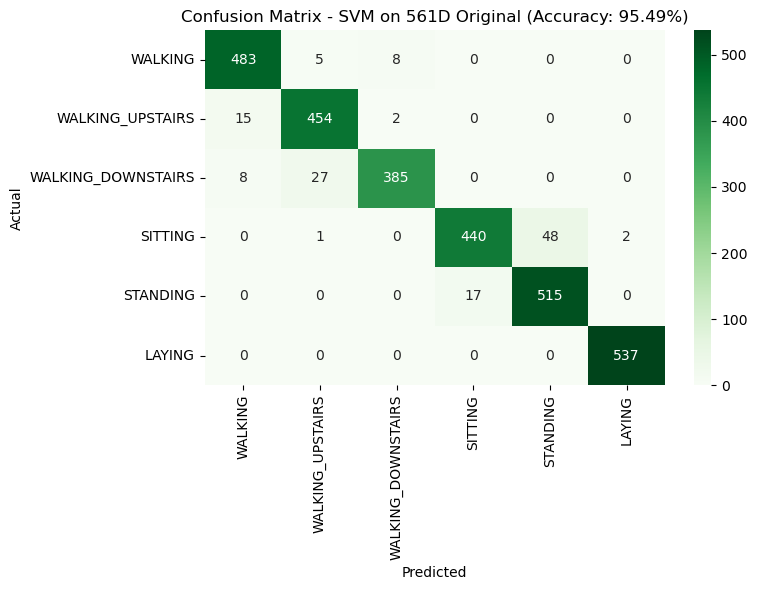

COMPARISON:
  Original 561D features: 95.49%
  AE 2D features:         78.15%
  Accuracy difference:    17.34%


In [13]:
svm_original = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_original.fit(X_train_scaled, y_train_flat)

y_pred_svm_original = svm_original.predict(X_test_scaled)
acc_svm_original = accuracy_score(y_test_flat, y_pred_svm_original)

print(f"SVM Accuracy on Original 561D Features: {acc_svm_original:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_flat, y_pred_svm_original, target_names=activity_labels["activity"].values))

cm_original = confusion_matrix(y_test_flat, y_pred_svm_original)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Greens',
            xticklabels=activity_labels["activity"].values,
            yticklabels=activity_labels["activity"].values)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - SVM on 561D Original (Accuracy: {acc_svm_original:.2%})')
plt.tight_layout()
plt.show()


print(f"COMPARISON:")
print(f"  Original 561D features: {acc_svm_original:.2%}")
print(f"  AE 2D features:         {acc_svm_ae:.2%}")
print(f"  Accuracy difference:    {(acc_svm_original - acc_svm_ae):.2%}")

## Part V. Extended Experiment: Latent Dimension = 16
Train a second autoencoder with 16D latent space and compare precision/accuracy with the 2D model.

In [14]:
latent_dim_16 = 16

encoder16_input = Input(shape=(input_dim,))
x = Dense(280, activation='relu')(encoder16_input)
x = Dense(140, activation='relu')(x)
x = Dense(64, activation='relu')(x)
latent16 = Dense(latent_dim_16, activation='linear', name='latent16')(x)
encoder16 = Model(encoder16_input, latent16, name='encoder16')

decoder16_input = Input(shape=(latent_dim_16,))
x = Dense(64, activation='relu')(decoder16_input)
x = Dense(140, activation='relu')(x)
x = Dense(280, activation='relu')(x)
decoder16_output = Dense(input_dim, activation='linear')(x)
decoder16 = Model(decoder16_input, decoder16_output, name='decoder16')

ae16_input = Input(shape=(input_dim,))
ae16_output = decoder16(encoder16(ae16_input))
autoencoder16 = Model(ae16_input, ae16_output, name='autoencoder16')
autoencoder16.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop_16 = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history_ae_16 = autoencoder16.fit(
    X_train_scaled,
    X_train_scaled,
    epochs=200,
    batch_size=128,
    validation_data=(X_test_scaled, X_test_scaled),
    callbacks=[early_stop_16],
    verbose=1
)

Epoch 1/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.6820 - mae: 0.5878 - val_loss: 0.3736 - val_mae: 0.3747
Epoch 2/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.3703 - mae: 0.3629 - val_loss: 0.3178 - val_mae: 0.3352
Epoch 3/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.3102 - mae: 0.3232 - val_loss: 0.2947 - val_mae: 0.3206
Epoch 4/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2854 - mae: 0.3104 - val_loss: 0.2802 - val_mae: 0.3168
Epoch 5/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2729 - mae: 0.3051 - val_loss: 0.2694 - val_mae: 0.3087
Epoch 6/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2569 - mae: 0.2951 - val_loss: 0.2598 - val_mae: 0.3028
Epoch 7/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2438 - mae: 0.2877 - val_loss: 0.2523 - val_mae: 0.2976
Epoch 8/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2358 - mae: 0.2831 - val_loss: 0.2460 - val_mae: 0.2939
Epoch 9/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - lo

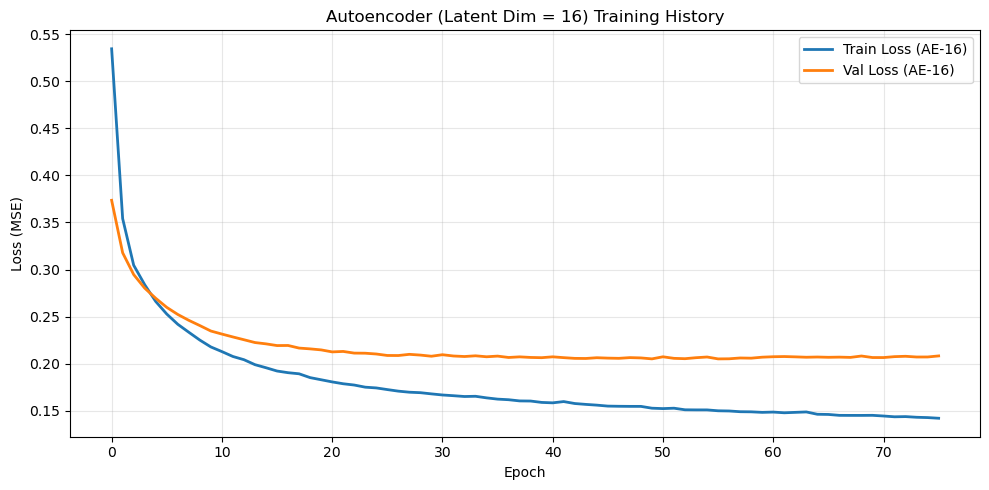

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(history_ae_16.history['loss'], label='Train Loss (AE-16)', linewidth=2)
plt.plot(history_ae_16.history['val_loss'], label='Val Loss (AE-16)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Autoencoder (Latent Dim = 16) Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

AE latent=16 -> SVM accuracy: 0.9077, weighted precision: 0.9081
AE latent=2  -> SVM weighted precision: 0.8004


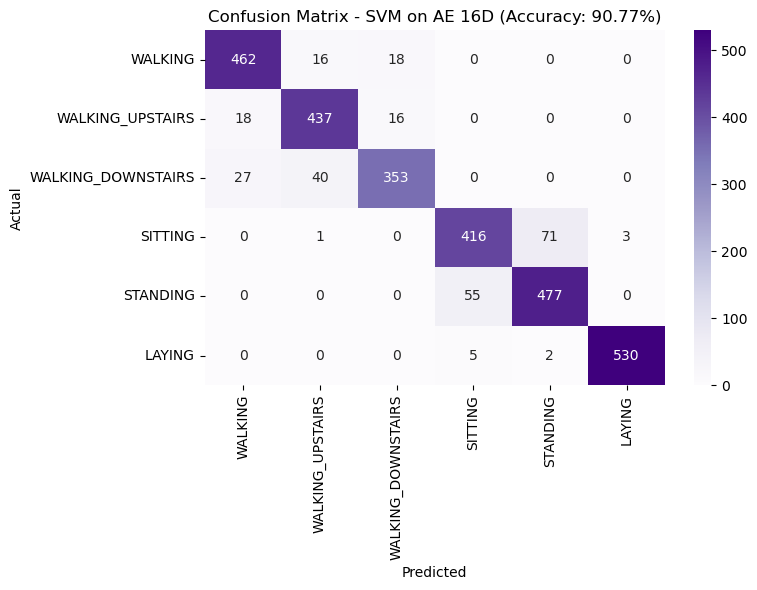

In [16]:
X_train_latent16 = encoder16.predict(X_train_scaled, verbose=0)
X_test_latent16 = encoder16.predict(X_test_scaled, verbose=0)

svm_ae_16 = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_ae_16.fit(X_train_latent16, y_train_flat)
y_pred_svm_ae_16 = svm_ae_16.predict(X_test_latent16)

acc_svm_ae_16 = accuracy_score(y_test_flat, y_pred_svm_ae_16)
precision_svm_ae_16 = precision_score(y_test_flat, y_pred_svm_ae_16, average='weighted')

precision_svm_ae_2d = precision_score(y_test_flat, y_pred_svm_ae, average='weighted')

print(f"AE latent=16 -> SVM accuracy: {acc_svm_ae_16:.4f}, weighted precision: {precision_svm_ae_16:.4f}")
print(f"AE latent=2  -> SVM weighted precision: {precision_svm_ae_2d:.4f}")

cm_ae_16 = confusion_matrix(y_test_flat, y_pred_svm_ae_16)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_ae_16,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=activity_labels["activity"].values,
    yticklabels=activity_labels["activity"].values
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - SVM on AE 16D (Accuracy: {acc_svm_ae_16:.2%})')
plt.tight_layout()
plt.show()

# Notebook Summary

This notebook builds an end-to-end representation learning pipeline on the UCI HAR dataset using autoencoders.

## What was done

1. Imported required libraries for data handling, deep learning, visualization, and ML evaluation.
2. Downloaded and extracted UCI HAR data if not already available.
3. Loaded train/test splits and activity labels, cleaned feature names, and built a combined dataframe `df` for inspection.
4. Standardized the 561 input features with `StandardScaler`.
5. Built and trained a 2D autoencoder (`561 -> 280 -> 140 -> 64 -> 16 -> 2`) with early stopping.
6. Visualized training and validation reconstruction loss curves.
7. Projected the data to 2D latent space and plotted class-colored latent points.
8. Trained and evaluated SVM classifiers on:
   - 2D AE latent features
   - Original 561D standardized features
9. Built and trained a second autoencoder with 16D latent space and evaluated SVM on 16D latent features.

## Main findings

- The 2D latent space shows visible structure and partial class separation.
- SVM on original 561D features gives the strongest baseline performance.
- SVM on AE latent features provides a compact representation-performance tradeoff.
- In this run, latent dimension 16 performed much better than latent dimension 2 (approximately 95% vs 75% weighted precision).

## Takeaway

Autoencoder-based reduction is useful for compact, interpretable embeddings, but extreme compression to 2D can lose discriminative information. A moderate latent space (like 16D) can preserve much more classification performance while still reducing dimensionality substantially.